In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
import os
import pickle
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import OptimalBattery.estimate as es
import Functional_Fusion.dataset as fdata
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.model as model
from collections import defaultdict
import cortico_cereb_connectivity.evaluation as con_ev
import OptimalBattery.construct as ct
import OptimalBattery.plot as plot


Default device set to: cuda


# define atlas and dirs

In [2]:
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')
connectivity_dir = os.path.join(base_dir, 'OptimalBattery', 'connectivity')
#check if the directories exist
if not os.path.exists(connectivity_dir):
    os.makedirs(connectivity_dir)
MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')


In [3]:
subj_list = ['sub-02','sub-03']

In [4]:
space = 'SUIT3'
suit_atlas,_= am.get_atlas(atlas_str=space)

data_mdtb_s1_run_suit,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun',subj=subj_list)
data_mdtb_s1_run_suit[np.isnan(data_mdtb_s1_run_suit)] = 0



data_mdtb_s1_all_suit,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll',subj=subj_list)
data_mdtb_s1_all_suit[np.isnan(data_mdtb_s1_all_suit)] = 0


data_mdtb_s2_all_suit,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll',subj=subj_list)
data_mdtb_s2_all_suit[np.isnan(data_mdtb_s2_all_suit)] = 0


In [5]:
space ='fs32k'
fs_atlas,_= am.get_atlas(atlas_str=space)
data_mdtb_s1_run_fs,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun',subj=subj_list)
data_mdtb_s1_run_fs[np.isnan(data_mdtb_s1_run_fs)] = 0

data_mdtb_s1_all_fs,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll',subj=subj_list)
data_mdtb_s1_all_fs[np.isnan(data_mdtb_s1_all_fs)] = 0

data_mdtb_s2_all_fs,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll',subj=subj_list)
data_mdtb_s2_all_fs[np.isnan(data_mdtb_s2_all_fs)] = 0

In [6]:
data_mdtb_s1_run_fs = ut.recenter_fmri_data(data_mdtb_s1_run_fs,info_mdtb_1_run,task_column_name='cond_name',center_condition='rest')
data_mdtb_s1_all_fs = ut.recenter_fmri_data(data_mdtb_s1_all_fs,info_mdtb_1_all,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_run_fs.shape)
print(data_mdtb_s1_all_fs.shape)

(2, 464, 59518)
(2, 29, 59518)


# Get crossvalidated second moment matrix (GLib)

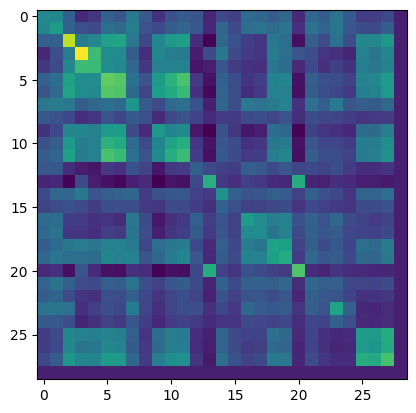

In [7]:
G_lib =  ct.get_G(data=data_mdtb_s1_run_fs,n_cond=29,n_part=16)
plt.imshow(G_lib)

In [9]:
condition_df= ct.get_condition_indices(info_mdtb_1_run)

In [10]:
D = ev.real_connectivity(G_lib, condition_df,
                      data_mdtb_s1_run_fs,data_mdtb_s1_run_suit, # training data
                      data_mdtb_s2_all_fs,data_mdtb_s2_all_suit, # test data
                      battery_sizes = [3,4],
                      metrics  = ['random','variance','variance_mc','log_det_mc','inverse_trace_mc'],
                      n_batteries = 1000,
                      rest_idx = 28,
                      n_iter=2)


Evaluating battery size: 3
Iteration: 0
Evaluating metric: random
Evaluating metric: variance
Evaluating metric: variance_mc
Evaluating metric: log_det_mc
Evaluating metric: inverse_trace_mc
Iteration: 1
Evaluating metric: random
Evaluating metric: variance
Evaluating metric: variance_mc
Evaluating metric: log_det_mc
Evaluating metric: inverse_trace_mc
Evaluating battery size: 4
Iteration: 0
Evaluating metric: random
Evaluating metric: variance
Evaluating metric: variance_mc
Evaluating metric: log_det_mc
Evaluating metric: inverse_trace_mc
Iteration: 1
Evaluating metric: random
Evaluating metric: variance
Evaluating metric: variance_mc
Evaluating metric: log_det_mc
Evaluating metric: inverse_trace_mc


In [11]:
D_averaged_across_iter = averaged_df = plot.average_per_subject(D,'correlation') # lists of subjects are averaged across iterations
long_df = averaged_df.explode('avg_correlation_per_subject') # expands the list of subjects into rows for each subject
long_df['avg_correlation_per_subject'] = long_df['avg_correlation_per_subject'].astype(float) # turns each correaltion for each subject into a float 

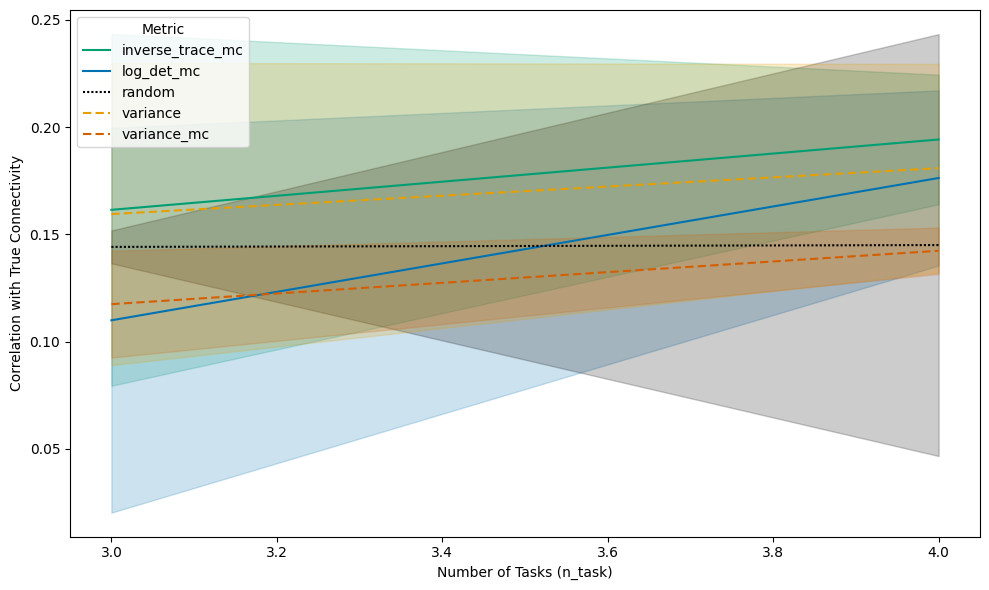

In [12]:
custom_palette = {
    'random': 'black',
    'variance': '#E69F00',
    'variance_mc': '#D55E00',
    'log_det_mc': '#0072B2',
    'inverse_trace_mc': '#009E73'
}

custom_dashes = {
    'random': (1, 1),            # dotted
    'variance': (4, 2),              # dashed
    'variance_mc': (4, 2),           # dashed
    'log_det_mc': '',        # solid
    'inverse_trace_mc': '',  # solid
}

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=long_df,
    x="n_task",
    y="avg_correlation_per_subject",
    hue="metric",
    style="metric",
    palette=custom_palette,
    dashes=custom_dashes
)

plt.xlabel("Number of Tasks (n_task)")
plt.ylabel("Correlation with True Connectivity")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()